<img src="./logo_UTN.svg" align="right" width="150" /> 

# Tarea Semanal I

#### Teoría de Circuitos II
#### Curso R4052
#### Facultad Regional de Buenos Aires



Autor: *Martín Sebastián Little*

### Introducción

En este trabajo, se realizará el análisis de un circuito Pasabajos de orden seis, empezando por su transferencia genérica, diagrama de polos y respuestas de amplitud y de fase. Luego, se analizará la red circuital compuesta por los filtros Sallen-key, filtro Variable de estado y el filtro Multiple Feedback.

### Transferencia de orden n = 6

A partir del análisis del circuito pasa-bajos de orden dos, compuestos por una resistencia, una bobina y un capacitor en serie y siendo este último el de salida, planteamos la siguiente expresión:

### $T(s) = \frac{Z_2}{Z_1 + Z_2}$

### $\begin{cases} Z_1 + Z_2 = Z_s =  R + sL + \frac{1}{sC} & \quad (1) \\ Z_1 = \frac{1}{sC} & \quad (2) \end{cases}$ 

De esta manera, reemplazando los valores en la ecuación de la transferencia y normalizando el polinomio del denominador, obtenemos la siguiente expresión:

### $T(s) = \frac{\frac{1}{L.C}}{s².L.C + \frac{s.R}{L} + \frac{1}{L.C}}$

Y expresando en función de Q (factor de selectividad) y wo (velocidad angular) obtenemos:

### $T(s) = \frac{wo²}{s² + \frac{wo}{Q} + wo²}$

Ya que cada red circuital tipo RLC representa un par de orden, ponemos tres de estas redes circuitales en serie, obteniendo el Pasabajos de orden seis deseado:

### $T(s) = \frac{K_1.wo_1²}{s² + \frac{wo_1}{Q_1} + wo_1²} + \frac{K_2.wo_2²}{s² + \frac{wo_2}{Q_2} + wo_2²} + \frac{K_3.wo_3²}{s² + \frac{wo_3}{Q_3} + wo_3²}$

donde K son constantes reales que permiten ajustar el nivel de la banda de paso. En otras palabras, la constante K indica qué tanta ganancia posee el circuito.


### Diagrama de Polos y ceros, Respuesta de Amplitud, Respuesta de Fase y Retardo de Grupo

Al estar trabajando con un Pasabajos de orden seis, podemos pensar que tenemos seis pares de polos en el diagrama o, en su defecto, tres pares de polos tomando solo el semieje de las abcisas. 

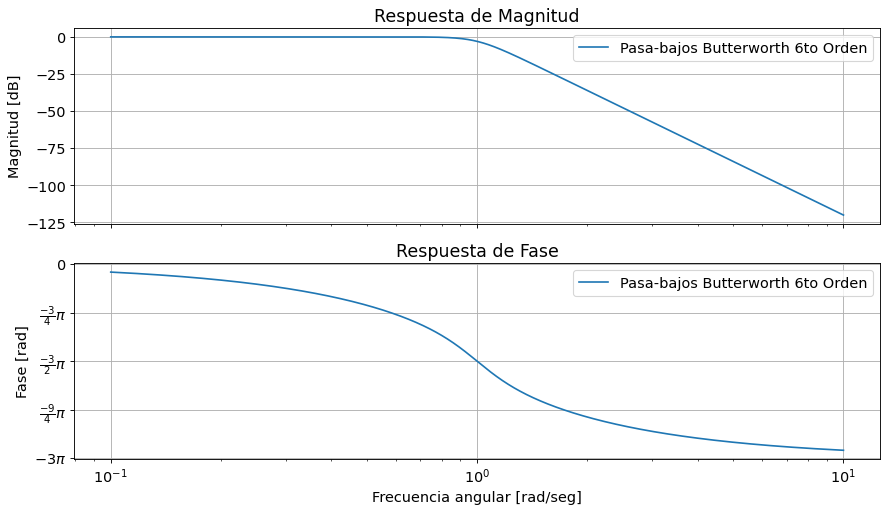

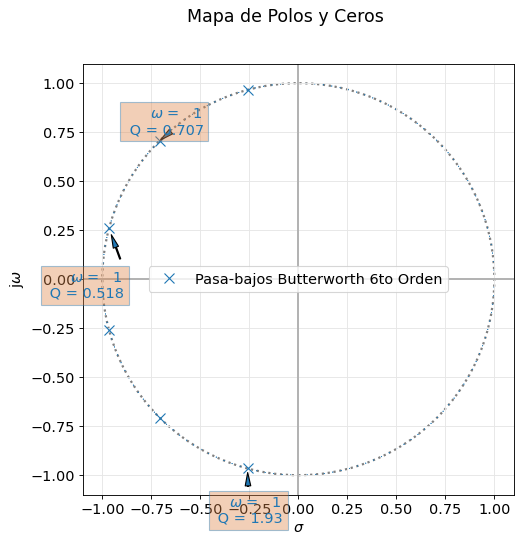

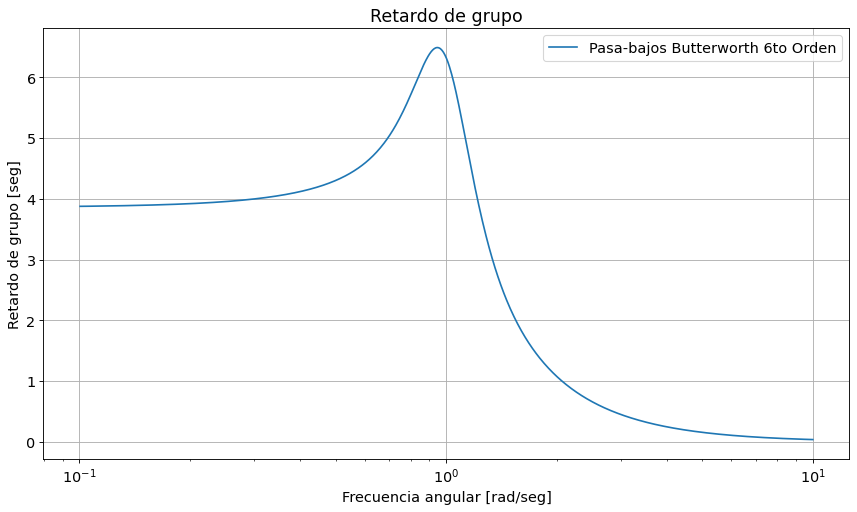

In [5]:
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from scipy import signal as sig

# Librería de la cátedra (UTN/UBA)
from pytc2.sistemas_lineales import analyze_sys

# Configuración de estilo (la mantenemos igual)
fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 
fig_font_size = 13
mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

# --- COMIENZO DE LA SIMULACIÓN NORMALIZADA ---

orden = 6
# Frecuencia angular normalizada
w0 = 1.0 

# El primer valor es el coeficiente de 's', el segundo es el término independiente.
num, den = sig.butter(orden, w0, btype='low', analog=True, output='ba')
H_butter = sig.TransferFunction(num, den)

# analyze_sys hace todo: diagrama de Bode (módulo y fase), polos y ceros y respuesta al impulso.
analyze_sys(H_butter, sys_name='Pasa-bajos Butterworth 6to Orden');

### Red Circuital 

Como se anticipó antes, para armar la red circuital del filtro pasabajos de orden seis, se usarán para cada etapa un filtro distinto que estarán separados por buffers unos de otros. El criterio de diseño que nos impone el enunciado es que el factor de selectividad de la siguiente etapa debe ser mayor al de la actual. En otras palabras:

$ Q_1 < Q_2 < Q_3 $

#### Transferencia de Filtro Sallen-Key

Tomando de la bibliografía disponible por la cátedra, obtenemos que la transferencia normalizada del filtro Sallen-Key es la siguiente:

## $$T_1(s) =K. \frac{\frac{G_1.G_2}{C_1.C_2}}{s² + \frac{s.(G_1.C_1.G_2.C_2+G_2.C_2.(1-k)}{C_1.C_2} + \frac{1}{G_1.G_2.C_1.C_2}}$$

#### Transferencia Filtro Variable de Estado (KHN)

## $$T_2(s) = \frac{\frac{R_3}{C_1 \cdot C_2 \cdot R_1 \cdot R_4 \cdot R_5}}{s^2 + s \cdot (1 + \frac{R_3}{R_1} + \frac{R_3}{R_2}) \cdot \frac{R_7}{C_1 \cdot R_4 \cdot (R_6 + R_7)} + \frac{R_3}{R_2} \cdot \frac{R_3}{C_1 \cdot C_2 \cdot R_2 \cdot R_4 \cdot R_5}}$$

#### Transferencia Filtro Multiple Feedback (MFB)

## $$T_3(s) = \frac{-\frac{G_2 G_3}{C_1 C_2}}{s^2 + s \cdot \left[ \frac{G_1}{C_1} + \frac{G_3}{C_1} + \frac{G_2}{C_1} \right] + \frac{G_1 G_2}{C_1 C_2}}$$

### Normalización de Red Circuital

#### Normalización de Filtro Sallen-Key

$$\Omega_z = 1 \quad \text{y} \quad \Omega_w = \omega_0 = 1 \qquad\qquad f_c = \frac{1}{2\pi \cdot R \cdot C} = 0,159\text{ Hz}$$

$$\begin{cases} 
Q = \frac{1}{2 \cdot \cos(\pi/12)} = 0,5176 \approx 0,518 \\[1ex]
R_1 = R_2 = 1 = R_3 \\ 
C_1 = C_2 = C = 1 \\ 
\omega_0 = 1 \\[1ex]
K = 1 + \frac{R_4}{R_3} \longrightarrow R_4 = 0,065
\end{cases}
\longrightarrow \frac{3-K}{R \cdot C} = \frac{\omega_0}{Q}$$

$$-K = \frac{1}{Q} - 3$$

$$K = 3 - 1/Q \longrightarrow K = 1,065$$

Observación: Notamos que los valores al ser tan pequeños, si se realiza un redondeo o se modifican los mismos, la ganancia puede modificarse de manera radical. Si se coloca, por ejemplo, una resistencia R4 de 0,07 obtendremos una ganancia mucho mas cercana a 1,6.
#### Normalización Filtro Variable de Estado (KHN)

$$
\begin{aligned}
&\Omega_\omega = \omega_{o2} = 1 \text{ rad/seg} \\
&\Omega_z = R_1 = R_2 = R_3 = 1 \quad \rightarrow \quad K = -\frac{R_2}{R_1} = 1 \\
&\Omega_c = C_1 = C_2 = 1 \\
&\omega_{o2} = 1 = \frac{1}{\sqrt{R_4 \cdot R_5 \cdot C_1 \cdot C_2}} \\[15pt]
&\begin{cases} 
R_4 \cdot R_5 \cdot C_1 \cdot C_2 = 1 \quad \rightarrow \quad R_4 \cdot R_5 = 1 \\
\frac{\omega_o}{Q} = \frac{1}{R_4 \cdot C_1} \cdot \left( \frac{R_7}{R_6 + R_7} \right) \cdot \underbrace{\left( 1 + \frac{R_3}{R_1} + \frac{R_3}{R_2} \right)}_{= 3} \\
R_4 = R_5 = 1
\end{cases} \\[15pt]
&\frac{2}{\sqrt{2}} \cdot \frac{1}{3} = \frac{1}{R_4} \cdot \left( \frac{R_7}{R_6 + R_7} \right) \\[5pt]
&\frac{2}{3} \cdot \frac{1}{\sqrt{2}} = \frac{R_7}{R_6 + R_7} \quad \text{con } R_7 = 1 \\[5pt]
&\frac{2}{3} \cdot \frac{1}{\sqrt{2}} = \frac{1}{R_6} \quad \rightarrow \quad R_6 = 1,1213
\end{aligned}
$$

#### Normalización Filtro Multiple Feedback:

$$Q = \frac{1}{2 \cdot \cos(5\pi/12)} = 1,9318$$

$$\begin{cases}
\frac{\omega_0}{Q} = \frac{1}{C_1} \cdot \left( \frac{1}{R_1} + \frac{1}{R_2} + \frac{1}{R_3} \right) \\[1.5ex]
\text{la ganancia es } K = -\frac{R_1}{R_3}
\end{cases}$$

$$\omega_0 = 1\text{ rad/s}$$

Considerando que por enunciado nos dicen que la ganancia debe ser de 10db, calculamos cuánto tendría que ser la ganancia K3 para que se cumpla esto:

$$ K_1.K_2.K_3 = 1,06.1.K3 = 10db -> K_3 = 2,9533$$

De esta manera, elejimos la normalización para cumplir tanto con la ganancia como el factor Q:

$\omega_0 = \frac{1}{\sqrt{R_1 \cdot R_2 \cdot C_1 \cdot C_2}}$

$\frac{\omega_0}{Q} = \frac{1}{C_1} \cdot \left( \frac{1}{R_1} + \frac{1}{R_2} + \frac{1}{R_3} \right)$

$K = \frac{R_1}{R_3}$

$K_1 \cdot K_2 \cdot K_3 = 1,06 \cdot 1 \cdot K_3 = 10\text{ dB}$

$10^{10/20} = 3,16 \longrightarrow K_3 = 2,9533$

$K_3 = \frac{R_1}{R_3} = 2,9533 \longrightarrow \begin{cases} R_3 = R_2 = 1 \\ R_1 = 2,9533 \end{cases}$

$\omega_0 = 1 \longrightarrow 1 = R_1 \cdot R_2 \cdot C_1 \cdot C_2$

$1 = 2,9533 \cdot 1 \cdot C_1 \cdot C_2 \longrightarrow C_1 \cdot C_2 = 0,3386$

$\frac{1}{1,9318} = \frac{1}{C_1} \cdot \left( 2 + \frac{1}{2,9533} \right) \longrightarrow C_1 = 1,9318 \cdot 2,3386$

$C_1 = 4,5177$

$C_2 = \frac{0,3386}{C_1} = 0,075$ 

### Simulación Filtro Sallen-Key

Al observar la ganancia que se tiene en la frecuencia de corte, la cuál es 159mHz, observamos una ganancia de 1,04568 la cuál es próxima al valor de 1,065 calculados.

<img src="./Fotos/Ganancia_Filtro_Sallen_Key.png" width = "800" /> 

### Simulación Filtro KHN

Al realizar las simulaciones, se puede observar que la ganancia en la frecuencia de corte es la esperable según los cálculos realizados, la cuál es de -3db, es decir, un K = 1.

<img src="./Fotos/Ganancia_Filtro_KHN.png" width = "800" /> 




### Simulación Filtro MFB

<img src="./Fotos/Ganancia_Filtro_MFB.png" width = "800" /> 

Hecha la normalización de los valores, al simular el circuito correspondiente, se observa una ganancia mucho mayor en la frecuencia de resonancia o frecuencia de corte del filtro calculada analíticamente, pero si analizamos mas a detalle, como el Q es mayor a 0,707 estamos ante un circuito subamortiguado, es decirHecha, un circuito en donde en la frecuencia de resonancia o frecuencia de corte aparece un sobrepico.
Analizando mas a detalle este sobrepico:

$$ 20.log(\frac{1}{Q}) = 5,72db $$
$$ 15,13db - 5,72db = 9,41db$$ 

Que si lo pasamos a veces, obtenemos que:
$$ K_3 = 10^( \frac{9,41}{20} ) = 2,9546$$

El cuál es un valor de ganancia muy próximo al que estábamos buscando.

### Conexión Final: Configuración Cascada de Filtros

Si conectamos en cascada todos los filtros diseñados separados por buffers, observamos que tenemos 0,89db antes de acercarnos a la frecuencia de corte, valor esperado y solicitado por el enunciado.



<img src="./Fotos/Ganancia_Filtro_Cascada_Completa.png" width = "800" /> 


### Conclusiones

En esta presentación se pudo realizar correctamente las normalizaciones de cada uno de los circuitos, y se pudo observar la inferencia que tiene en las simulaciones y los circuitos el factor de calidad Q, donde se pudo apreciar que en aquellos filtros que se analizaron de manera individual con factores mas altos, la frecuencia de resonancia y los sobrepicos eran mas notorios que en otros casos. Sin embargo, en los casos donde el Q correspondía a filtros Butterworth o incluso menores a ellos, el mismo no se notaba.